# Get To Know A Dataset: OVRO LWA Solar Observation

This notebook is a guided tour of the [OVRO LWA Solar Observation](https://registry.opendata.aws/ovrolwasolar) dataset. More usage examples, tutorials, and documentation for this dataset and others can be found at the [Registry of Open Data on AWS](https://registry.opendata.aws/).

Public data are hosted in the [`ovro-lwa-solar`](https://ovro-lwa-solar.s3.us-west-2.amazonaws.com/index.html) S3 bucket in `us-west-2`. The examples below download representative sample files directly from the bucket.


## Q: How have you organized your dataset? Help us understand the key prefix structure of your S3 bucket.

The OVRO LWA Solar Observation dataset contains low-frequency solar radio products from the Owens Valley Radio Observatory Long Wavelength Array. The release contains long-term solar observing products derived from beamformed spectroscopy and interferometric imaging.

The public bucket is [`s3://ovro-lwa-solar/`](https://ovro-lwa-solar.s3.us-west-2.amazonaws.com/index.html). Image products are partitioned by observation date using `YYYY/MM/DD` prefixes, while all-day spectrogram products are grouped by year. The current layout is:

```text
s3://ovro-lwa-solar/
  image_hdf/YYYY/MM/DD/filename
  spec_fits/YYYY/YYYYMMDD.fits
```

The main product groups currently published are:

- `image_hdf`: interferometric spectral image products in HDF format, including band-averaged image products such as `mfs` and fine-channel image products such as `fch`.
- `spec_fits`: all-day total-power spectrogram products in FITS format.

Representative file naming conventions are shown in the figures below and include:

- `ovro-lwa-352.lev1_mfs_10s.YYYY-MM-DDTHHMMSSZ.image_I.hdf`
- `YYYYMMDD.fits`


Figure: annotated naming convention for an OVRO-LWA HDF image product.

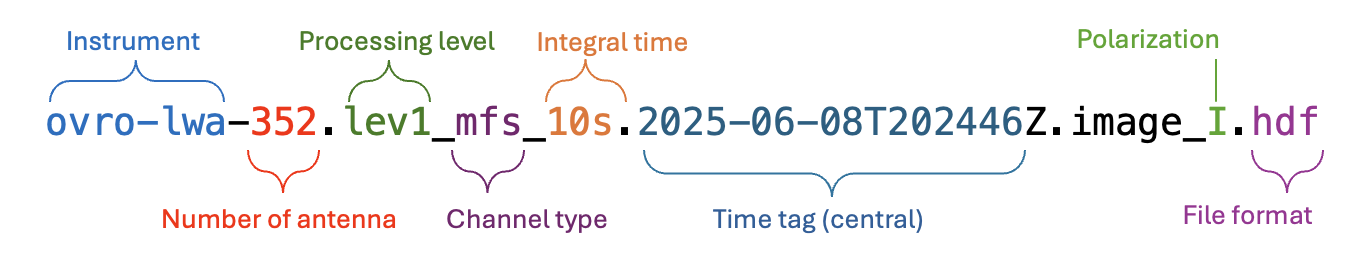

First we import the Python libraries used throughout this notebook.


In [ ]:
# This notebook requires the following libraries:
#
# boto3>=1.34
# botocore>=1.34
# h5py>=3.10
# matplotlib>=3.8
# numpy>=1.26
# astropy>=6.0
# sunpy>=6.0
# scipy>=1.11
# git+https://github.com/ovro-eovsa/lwa-solar-util.git

from pprint import pprint
import tempfile

import boto3
from botocore import UNSIGNED
from botocore.config import Config
import h5py
import matplotlib.pyplot as plt
import numpy as np


Next, we define the dataset location, create an unsigned boto3 S3 client for the public bucket, and explore the prefix structure from the top level down to representative data objects.


In [ ]:
from pathlib import Path

BUCKET = "ovro-lwa-solar"
SAMPLE_HDF_KEY = "image_hdf/2026/05/13/ovro-lwa-352.lev1_mfs_10s.2026-05-13T205344Z.image_I.hdf"
SAMPLE_SPEC_FITS_KEY = "spec_fits/2025/20250403.fits"

s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))


In [ ]:
# List top-level prefixes in the public bucket.
response = s3.list_objects_v2(Bucket=BUCKET, Delimiter="/", MaxKeys=100)
for prefix in response.get("CommonPrefixes", []):
    print(prefix["Prefix"])


Under `image_hdf/`, products are organized by observation date. Listing one day shows the per-timestamp HDF image files.


In [ ]:
IMAGE_DATE_PREFIX = "image_hdf/2026/05/13/"

response = s3.list_objects_v2(Bucket=BUCKET, Prefix=IMAGE_DATE_PREFIX, MaxKeys=5)
for item in response.get("Contents", []):
    print(item["Key"])


Under `spec_fits/`, all-day spectrogram products are grouped by year. The example below lists a few FITS files from 2025.


In [ ]:
SPEC_YEAR_PREFIX = "spec_fits/2025/"

response = s3.list_objects_v2(Bucket=BUCKET, Prefix=SPEC_YEAR_PREFIX, MaxKeys=5)
for item in response.get("Contents", []):
    print(item["Key"])


## Q: What data formats are present in your dataset? What kinds of data are stored using these formats? Can you give any advice for how you work with these data formats?

The data products use [FITS](https://fits.gsfc.nasa.gov/) and [HDF5](https://www.hdfgroup.org/solutions/hdf5/).

**FITS** is used for all-day total-power spectrogram products. The Level 1 spectrograms are standard FITS tables containing frequency, time, and Stokes I flux density in solar flux units (SFU). The Level 1.5 spectrograms add background subtraction and primary beam correction. FITS is a long-standing astronomy standard that integrates cleanly with solar-physics tooling and metadata conventions.

**HDF/HDF5** is used for standard interferometric spectral images. The fine-channel image products contain independent images at 144 frequency channels spanning 32 to 87 MHz, with 10 second integrations. The band-averaged image products contain 12 multi-frequency synthesis images with center frequencies from about 34.1 to 84.6 MHz. HDF5 was chosen because the image products contain many large arrays and groups that are efficiently stored, compressed, and accessed independently.

These image products are generated in heliocentric coordinates and can be converted to FITS using the OVRO-LWA utility package.

Recommended Python tooling:

- `h5py` for generic HDF5 inspection and array loading.
- `astropy` and `sunpy` for FITS and solar-coordinate workflows.
- `matplotlib` and `numpy` for quicklook visualization.
- `lwasolarutl` for OVRO-LWA specific HDF to FITS recovery and standard plotting helpers.

On AWS, users typically bulk-download products with Amazon S3, process them on Amazon EC2 or AWS Batch, and store derived products back in their own S3 buckets. For large-scale cataloging or metadata queries, [Amazon Athena](https://docs.aws.amazon.com/athena/) can be used once object metadata is indexed in a table, and [AWS Lambda](https://aws.amazon.com/lambda/) can trigger event-driven processing when new daily prefixes appear.


## Q: Can you show us an example of downloading and loading data from your dataset?

As an example, we download one HDF spectral image and one FITS all-day spectrogram:

- `s3://ovro-lwa-solar/image_hdf/2026/05/13/ovro-lwa-352.lev1_mfs_10s.2026-05-13T205344Z.image_I.hdf`
- `s3://ovro-lwa-solar/spec_fits/2025/20250403.fits`


In [ ]:
sample_hdf = Path(tempfile.gettempdir()) / Path(SAMPLE_HDF_KEY).name
sample_spec_fits = Path(tempfile.gettempdir()) / Path(SAMPLE_SPEC_FITS_KEY).name

s3.download_file(BUCKET, SAMPLE_HDF_KEY, str(sample_hdf))
print(f"Downloaded s3://{BUCKET}/{SAMPLE_HDF_KEY} to {sample_hdf}")

s3.download_file(BUCKET, SAMPLE_SPEC_FITS_KEY, str(sample_spec_fits))
print(f"Downloaded s3://{BUCKET}/{SAMPLE_SPEC_FITS_KEY} to {sample_spec_fits}")


First, inspect the internal structure of the downloaded HDF image product.


In [ ]:
def summarize_hdf(path, max_items=40):
    rows = []

    def visitor(name, obj):
        if len(rows) >= max_items:
            return
        if isinstance(obj, h5py.Dataset):
            rows.append({
                "path": name,
                "kind": "dataset",
                "shape": obj.shape,
                "dtype": str(obj.dtype),
            })
        elif isinstance(obj, h5py.Group):
            rows.append({"path": name, "kind": "group"})

    with h5py.File(path, "r") as handle:
        handle.visititems(visitor)
        attrs = dict(handle.attrs)

    print("File attributes:")
    pprint(attrs)
    print("\nObjects:")
    pprint(rows)


summarize_hdf(sample_hdf)


The FITS spectrogram file can be inspected with `astropy`. Each extension stores one frequency channel as a time series.


In [ ]:
from astropy.io import fits

with fits.open(sample_spec_fits) as hdul:
    print(f"FITS extensions: {len(hdul)}")
    print("First three extensions:")
    for hdu in hdul[1:4]:
        print(hdu.header.get('EXTNAME'), hdu.data.shape, hdu.data.dtype)


## Q: A picture is worth a thousand words. Show us a visual (or several!) from your dataset that either illustrates something informative about your dataset, or that you think might excite someone to dig in further.

For the spectral image product, we first recover a FITS image cube from the downloaded HDF file. Then we plot the standard OVRO-LWA quicklook panels.


In [ ]:
try:
    import lwasolarutl as lsu
except ImportError as exc:
    raise ImportError(
        "Install the OVRO-LWA utility package before running this section: "
        "python -m pip install git+https://github.com/ovro-eovsa/lwa-solar-util.git"
    ) from exc

recovered_fits = Path(tempfile.gettempdir()) / f"{sample_hdf.stem}.recovered.fits"
lsu.file.recover_fits_from_h5(str(sample_hdf), str(recovered_fits))
print(f"Recovered FITS image cube: {recovered_fits}")

fig, axes = lsu.visualization.slow_pipeline_default_plot(
    str(recovered_fits),
    add_logo=False,
)
fig.suptitle("OVRO-LWA spectral image HDF sample", y=0.98)
plt.show()


The all-day spectrogram FITS file contains high-cadence time-frequency structure. The plot below zooms into a short interval to show Stokes I and V.


In [ ]:
spec = lsu.spec.load_spectrum_fits(str(sample_spec_fits))
print("I shape:", spec.spec_I.shape, "V shape:", spec.spec_V.shape)
print("nfreq:", len(spec.freqs_mhz), "MHz range:", spec.freqs_mhz[0], "...", spec.freqs_mhz[-1])
print("ntime:", len(spec.times), "from", spec.times[0].iso, "to", spec.times[-1].iso)

fig, axes = lsu.visualization.plot_spec(
    spec,
    pct_hi_I=99.6,
    t_range_ratio=(0.523, 0.53),
    vi_range=(-0.6, 0.6),
)
fig.suptitle("OVRO-LWA all-day spectrum FITS sample", y=0.98)
plt.show()


These plotting calls mirror the OVRO-LWA examples in the upstream utility repository:

- HDF image plotting: https://github.com/ovro-eovsa/lwa-solar-util/blob/main/notebook/image_plot_hdf.ipynb
- FITS spectrum plotting: https://github.com/ovro-eovsa/lwa-solar-util/blob/main/notebook/spec_plot.ipynb

For publication-quality figures, use the domain-specific recovered FITS products and the solar-coordinate plotting utilities rather than the generic HDF object preview.


## Q: What is one question that you have answered using these data? Can you show us how you came to that answer?

One baseline question is: how does the peak brightness of low-frequency solar radio emission change across observing frequency during a selected time interval?

For a band-averaged spectral image product, we recover the FITS cube from the HDF file and compute the peak intensity in each of the 12 frequency planes. Lower frequencies generally correspond to radio emission from higher coronal heights, while higher frequencies sample lower coronal plasma.


In [ ]:
with fits.open(recovered_fits) as hdul:
    data = hdul[0].data
    header = hdul[0].header
    nfreq = data.shape[1]
    freqs_mhz = (float(header["CRVAL3"]) + float(header["CDELT3"]) * np.arange(nfreq)) / 1e6
    peak_sfu = [float(np.nanmax(data[0, i])) for i in range(nfreq)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freqs_mhz, peak_sfu, marker="o")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Peak brightness (SFU)")
ax.set_title("Peak intensity vs frequency for sample MFS image")
ax.grid(True, alpha=0.3)
plt.show()


## Q: What is one unanswered question that you think could be answered using these data? Do you have any recommendations or advice for someone wanting to answer this question?

Community challenge: build an open benchmark for detecting and classifying low-frequency solar radio burst activity from OVRO-LWA spectrogram and spectral-image products.

A useful first version would combine all-day spectrograms with image-derived context. The spectrograms provide high-cadence time-frequency structure, while the HDF image products provide spatial localization and frequency-dependent morphology. A model or rules-based detector could identify candidate burst intervals, classify broad burst families, and flag intervals that deserve higher-resolution imaging or manual review.

Recommended approach:

1. Start with a small date range and build an event table with observation date, time range, frequency range, product level, and data-quality notes.
2. Use Level 1.5 products when available for background-subtracted or refraction-corrected analysis, but keep Level 1 products for cases where Level 1.5 is not applicable during strong bursts.
3. Separate train, validation, and test periods by date to avoid leakage across adjacent solar activity intervals.
4. Keep the first benchmark simple: candidate detection, event/no-event labels, and quicklook plots. Add detailed event classes after the data-selection and annotation workflow is stable.

This challenge is realistic because it can begin with public products and does not require new observations.


## References

- OVRO LWA data portal: https://ovsa.njit.edu/lwa/
- OVRO-LWA Solar Data Products: https://www.ovsa.njit.edu/wiki/index.php/OVRO-LWA_Solar_Data_Products
- OVRO-LWA utility notebook: https://github.com/ovro-eovsa/lwa-solar-util/blob/main/notebook/image_plot_hdf.ipynb
- AWS Open Data tutorial template: https://github.com/awslabs/open-data-docs/tree/main/get-to-know-a-dataset
